In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1  # 导入一阶贝塞尔函数

In [2]:
def calculate_D(k, a1, a2, start=-np.pi / 2, stop=np.pi / 2, num=1000):
    """
    计算指向性函数
    参数：
        k: 波数
        a1: 半径1
        a2: 半径2
        start: 起始角度（默认 -π/2）
        stop: 终止角度（默认 π/2）
        num: 采样点数
    返回：
        theta数组和D数组
    """
    theta = np.linspace(start, stop, num)
    numerator = 2 * a2 * j1(k * a2 * np.sin(theta)) - 2 * a1 * j1(k * a1 * np.sin(theta))
    denominator = k * np.sin(theta) * (a2 ** 2 - a1 ** 2)
    # 处理分母为0的情况（使用掩码）
    mask = np.abs(denominator) < 1e-10
    D = np.zeros_like(theta)
    D[~mask] = np.abs(numerator[~mask] / denominator[~mask])
    D[mask] = 0  # 这里简单设为0，实际可根据极限情况调整
    return theta, D

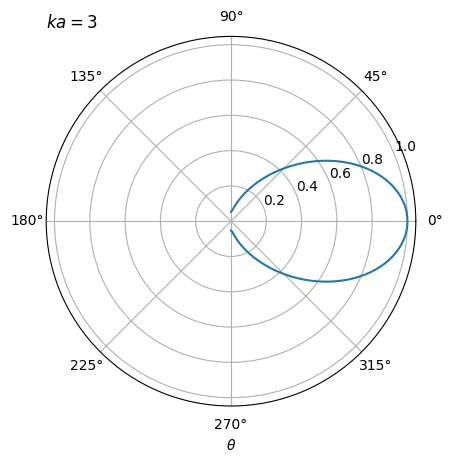

In [3]:
# 创建极坐标绘图画布
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')  # 通过projection='polar'创建极坐标系

# 计算并处理数据
theta, D = calculate_D(k=3, a1=0.5, a2=1.0)  # 修正参数传递方式
D = np.abs(D)                       # 取绝对值确保指向性值为正


# 绘制极坐标图
ax.plot(theta, D)                    # 在极坐标系中绘制角度-指向性曲线
ax.set_xlabel(r'$\theta$')          # 设置角度轴标签，使用LaTeX数学符号
ax.set_title(r'$ka=3$', loc='left')  # 左对齐标题，显示当前ka乘积值
ax.grid(True)                       # 开启极坐标网格
plt.show()                           # 显示完整图形

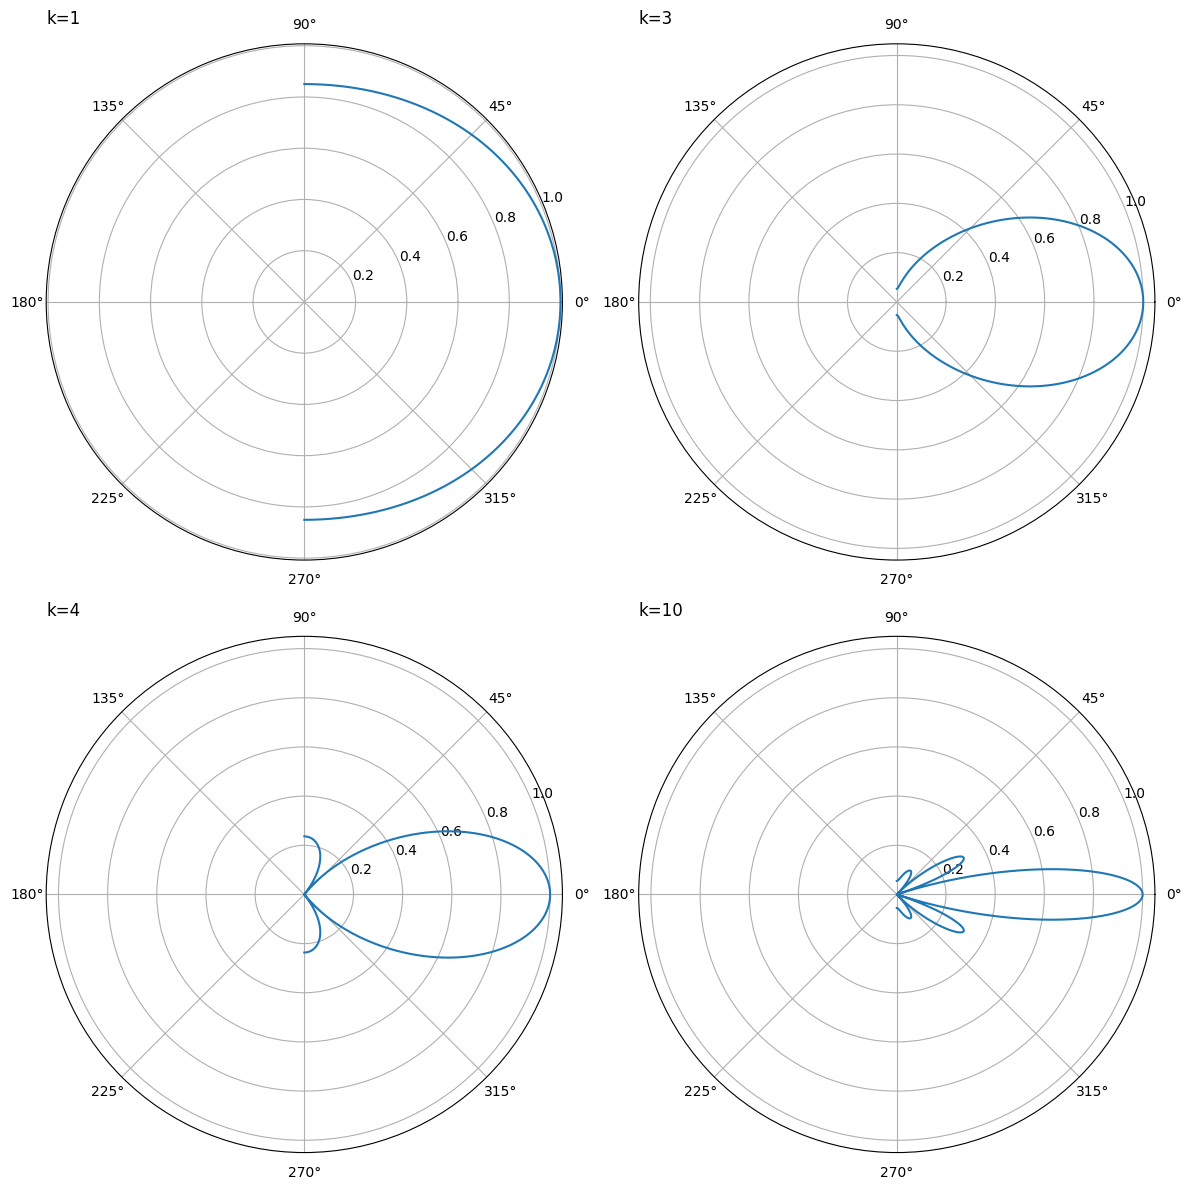

In [4]:
# 绘图
fig, axes = plt.subplots(2, 2, figsize=(12, 12),  # 新增figsize参数调整整体尺寸
                        subplot_kw={'projection': 'polar'})
# 固定 a1 和 a2 的值
a1 = 0.5
a2 = 1.0
k_values = [1, 3, 4, 10]

for ax, k in zip(axes.ravel(), k_values):
    # 修正参数传递，传入 k、a1 和 a2
    theta, D = calculate_D(k=k, a1=a1, a2=a2)
    D = np.abs(D)
    ax.plot(theta, D)
    ax.set_title(f'k={k}', pad=15, loc='left')  # 修改标题显示 k 值
    ax.grid(True)

plt.tight_layout()
plt.show()



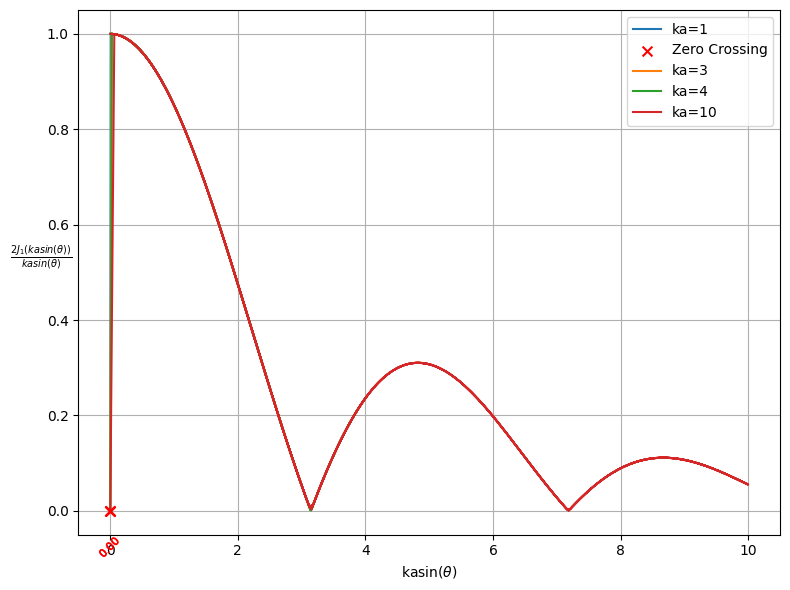

In [5]:
# 新增笛卡尔坐标系绘图
plt.figure(figsize=(8, 6))  # 新建画布
# 定义 ka_values
ka_values = [1, 3, 4, 10]
# 固定 a1 和 a2 的值
a1 = 0.5
a2 = 1.0

for ka in ka_values:
    # 计算 k 值，假设 a = 1
    k = ka
    # 修正参数传递，传入 k、a1 和 a2
    theta, D = calculate_D(k=k, a1=a1, a2=a2, start=0.0001, stop=np.pi*2, num=1000)
    x = np.abs(ka * np.sin(theta))
    plt.plot(x, D, label=f'ka={ka}')
   
    # 新增过零点检测
    zero_crossings = np.where(np.diff(np.sign(D)))[0]  # 检测符号变化点
    if len(zero_crossings) > 0:
        x_zeros = x[zero_crossings] + np.diff(x)[zero_crossings] * (-D[zero_crossings]/(D[zero_crossings+1] - D[zero_crossings]))
        plt.scatter(x_zeros, np.zeros_like(x_zeros), color='red', marker='x', s=50, zorder=5, label='Zero Crossing')
        
        # 新增数值标注
        for xz in x_zeros:
            plt.text(xz, -0.05, f'{xz:.2f}',  # 向下偏移0.05避免重叠
                    ha='center', va='top', 
                    rotation=45, fontsize=8,
                    color='red')

# 添加图例去重处理
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.xlabel(r'kasin($\theta$)')
plt.ylabel(r'$\frac{2J_1(kasin(\theta))}{kasin(\theta)}$', rotation=0)
plt.legend(by_label.values(), by_label.keys())
plt.grid(True)  
plt.tight_layout()
plt.show()


最后一个极大值的x坐标: 4.9950950950950945
最后一个极大值的y坐标: 2954064.486104271


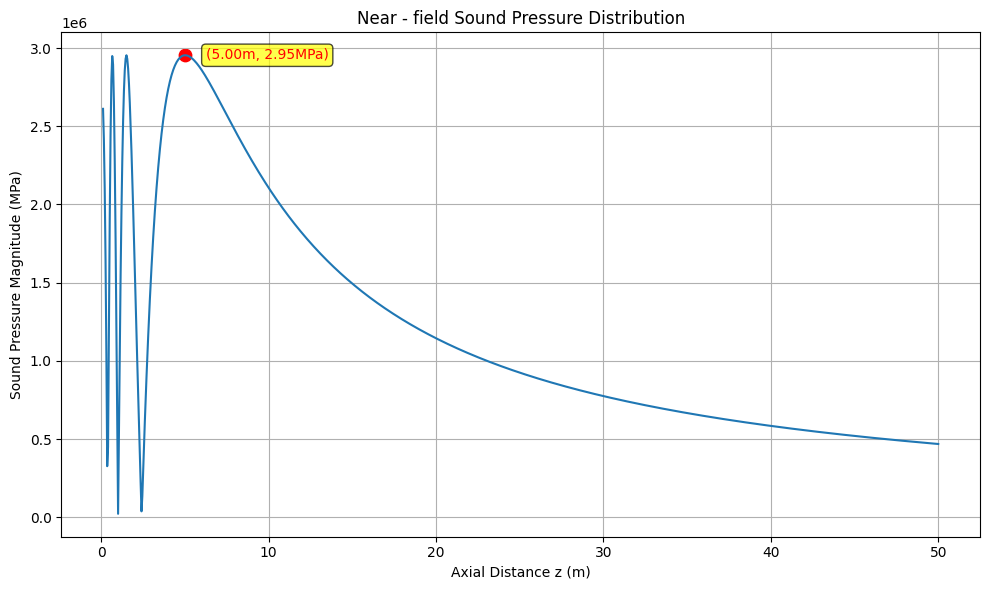

In [60]:
# 定义常量（水介质）
rho0 = 998  # 水密度（kg/m³）
C0 = 1480  # 水中声速（m/s）
ua = 1  # 速度幅值（假设值）
f = 10e3  # 频率（Hz）
w = 2 * np.pi * f  # 角频率
k = 2 * np.pi * f / C0  # 波数

# 半径假设值
a1 = 0.5
a2 = 1

def near_field_pressure(z, k, a1, a2):
    """
    根据给定的近场声压公式计算声压
    :param z: 轴向距离
    :param k: 波数
    :param a1: 半径1
    :param a2: 半径2
    :return: 声压值
    """
    h1 = np.sqrt(z ** 2 + a1 ** 2)
    h2 = np.sqrt(z ** 2 + a2 ** 2)
    p = -rho0 * C0 * ua * np.exp(1j * w * 0) * (np.exp(-1j * k * h2) - np.exp(-1j * k * h1))
    return p

# 轴向距离范围（调整为更适合水中高频的尺度）
z_values = np.linspace(0.1, 50, 1000)  # 从0.1mm到10mm

# 计算声压
pressure_values = np.array([near_field_pressure(z, k, a1, a2) for z in z_values])
pressure_magnitude = np.abs(pressure_values)

# 找到最后一个极大值的索引
diff_signal = np.diff(np.sign(np.diff(pressure_magnitude)))
maxima_indices = np.where(diff_signal == -2)[0] + 1  # 极大值点索引
if len(maxima_indices) > 0:
    last_max_index = maxima_indices[-1]
    last_max_x = z_values[last_max_index]
    last_max_y = pressure_magnitude[last_max_index]
    print(f"最后一个极大值的x坐标: {last_max_x}")
    print(f"最后一个极大值的y坐标: {last_max_y}")

# 绘图
plt.figure(figsize=(10, 6))  # 调整图表大小
plt.plot(z_values, pressure_magnitude)

# 标记最后一个极大值点
if len(maxima_indices) > 0:
    # 绘制极大值点
    plt.scatter(last_max_x, last_max_y, color='r', marker='o', s=80)
    
    # 在右侧添加文本注释
    plt.annotate(
        f'({last_max_x:.2f}m, {last_max_y/1e6:.2f}MPa)',
        xy=(last_max_x, last_max_y),
        xytext=(15, 0),  # 文本相对于点的偏移量（向右15个点）
        textcoords='offset points',
        fontsize=10,
        color='red',
        ha='left',  # 水平对齐方式：左对齐
        va='center',  # 垂直对齐方式：居中
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7)  # 添加黄色半透明背景
    )

plt.xlabel('Axial Distance z (m)')
plt.ylabel('Sound Pressure Magnitude (MPa)')
plt.title('Near - field Sound Pressure Distribution')
plt.grid(True)
plt.tight_layout()  # 确保标签不被截断
plt.show()